# Tutorial 5: MERFISH Aging multi-donor analysis

This executable tutorial visualizes compact, plot-ready inputs derived from the audited 31-section, 376,107-cell shared-loading fit. The full atlas is not distributed; the final section gives the local full-data fitting contract.

## Goal

Inspect a common rotated loading axis, map it in three real sections, and relate its scores to post hoc cell annotations. Program interpretation is descriptive: annotations were not used for fitting.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
ASSET_DIR = next(path for path in [Path('_static/merfish_aging_tutorial'), Path('source/_static/merfish_aging_tutorial')] if path.exists())
summary = json.loads((ASSET_DIR / 'model_summary.json').read_text())
scores = pd.read_csv(ASSET_DIR / 'three_section_P08_scores.csv.gz')
summary

/Users/era/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


{'n_cells': 376107,
 'n_sections': 31,
 'n_genes': 374,
 'n_components': 30,
 'converged': True,
 'n_iter': 51,
 'source': 'audited eta=0.02 shared-loading MERFISH fit'}

## 1. Full-data preprocessing and fitting contract

For a local rerun, split the normalized 374-gene MERFISH object by `slice_id`, take `obsm['spatial'][:, :2]` for each section, and fit the same 30-component hierarchical model. The published figures below use the converged saved result rather than silently re-fitting an atlas in the documentation build.

In [2]:
RUN_FULL_FIT = False
if RUN_FULL_FIT:
    import scanpy as sc
    from GraphPCA import Run_Hierarchical_Multi_GPCA
    adata = sc.read_h5ad('/path/to/MERFISH_Aging.h5ad')
    sections = [adata[adata.obs['slice_id'].eq(name)].copy() for name in adata.obs['slice_id'].unique()]
    locations = [one.obsm['spatial'][:, :2] for one in sections]
    Zs, W0, Ws, info = Run_Hierarchical_Multi_GPCA(
        sections, locations, n_components=30, lambdas=0.5, rhos=0.14872615,
        sample_weights='equal_slice', max_iter=50, random_seed=666, return_info=True)
    print(info.converged, info.n_iter)
else:
    print('Full atlas fit is intentionally disabled in the published tutorial.')

Full atlas fit is intentionally disabled in the published tutorial.


## 2. Map one common rotated program

`P08` is the eighth coordinate after one common rotation of the shared loading matrix and all section embeddings. The common rotation makes the displayed coordinate comparable across sections.

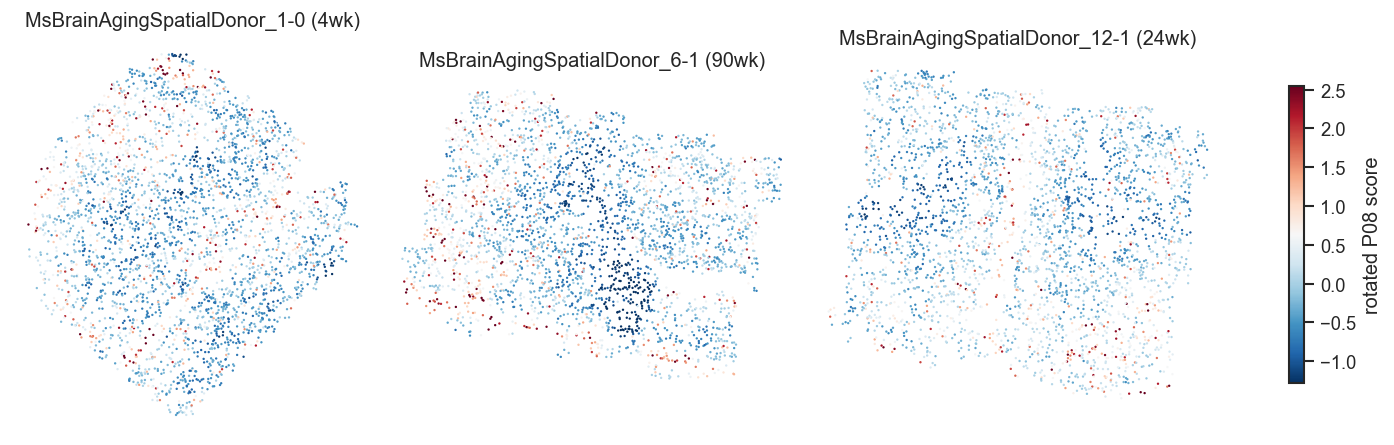

In [3]:
sections = scores['section'].drop_duplicates().tolist()
lo, hi = scores['P08'].quantile([0.01, 0.99])
fig, axes = plt.subplots(1, len(sections), figsize=(12, 3.6), constrained_layout=True)
for ax, section in zip(axes, sections):
    frame = scores.loc[scores.section.eq(section)]
    points = ax.scatter(frame.x, frame.y, c=frame.P08, s=2, cmap='RdBu_r', vmin=lo, vmax=hi, linewidths=0, rasterized=True)
    ax.set(title=f"{section} ({frame.age.iloc[0]})", aspect='equal'); ax.invert_yaxis(); ax.axis('off')
fig.colorbar(points, ax=axes, shrink=0.75, label='rotated P08 score')
plt.show()

## 3. Inspect leading genes

Loading signs and order are fixed only after the recorded common rotation. Positive leading genes provide molecular evidence for the displayed program; they do not by themselves establish a cell-state mechanism.

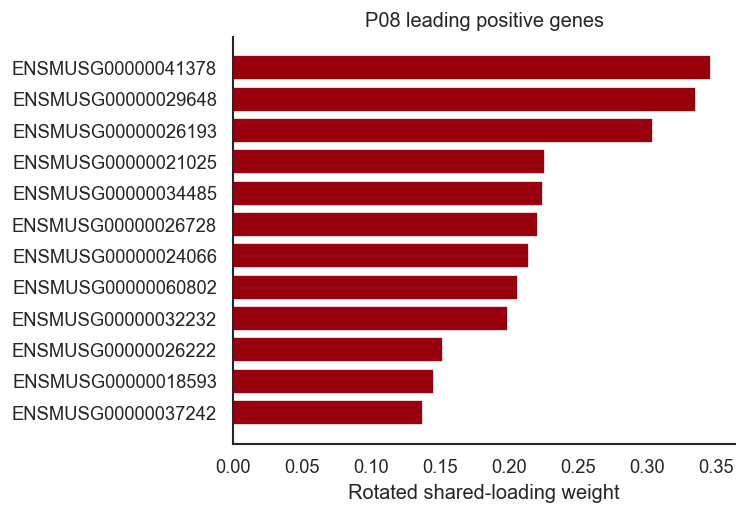

,gene,loading
0,ENSMUSG00000041378,0.346247
1,ENSMUSG00000029648,0.335178
2,ENSMUSG00000026193,0.304402
3,ENSMUSG00000021025,0.226214
4,ENSMUSG00000034485,0.224636


In [4]:
loadings = pd.read_csv(ASSET_DIR / 'P08_top_loadings.csv').sort_values('loading')
plt.figure(figsize=(5.4, 4.4))
plt.barh(loadings.gene, loadings.loading, color='#99000D')
plt.xlabel('Rotated shared-loading weight'); plt.title('P08 leading positive genes')
plt.show()
loadings.sort_values('loading', ascending=False).head()

## 4. Post hoc annotation summary

This section is a visualization aid only. It summarizes P08 within the observed annotations and makes no age, P24, causal, or absolute-activity claim.

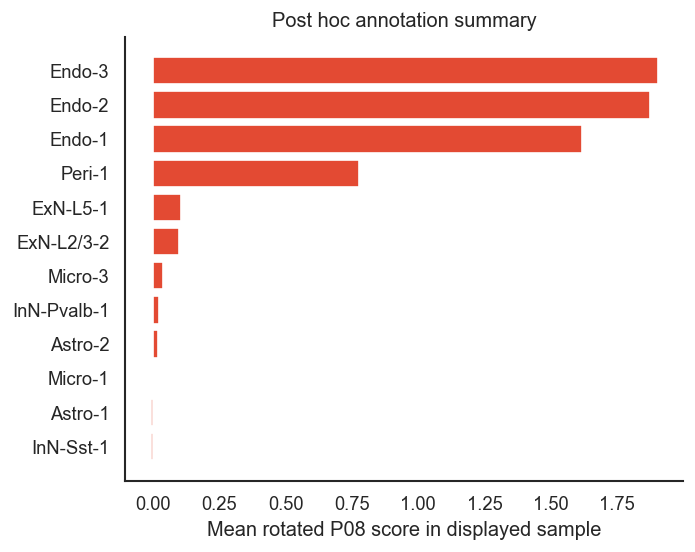

,clust_annot,mean_P08,n_cells
4,Endo-3,1.904121,185
3,Endo-2,1.873295,94
2,Endo-1,1.619176,477
39,Peri-1,0.776822,195
8,ExN-L5-1,0.104437,265
7,ExN-L2/3-2,0.098473,156
34,Micro-3,0.035658,122
22,InN-Pvalb-1,0.022532,97
1,Astro-2,0.018397,189
32,Micro-1,0.001711,164


In [5]:
annotation_summary = (scores.groupby('clust_annot', as_index=False)
    .agg(mean_P08=('P08', 'mean'), n_cells=('P08', 'size'))
    .query('n_cells >= 80').sort_values('mean_P08'))
plot = annotation_summary.tail(12)
plt.figure(figsize=(6, 4.8))
plt.barh(plot.clust_annot, plot.mean_P08, color='#E34A33')
plt.xlabel('Mean rotated P08 score in displayed sample'); plt.title('Post hoc annotation summary')
plt.show()
plot.sort_values('mean_P08', ascending=False)

## Checks and caveats

The compact assets are deterministic samples from the converged, audited fit. They support visualization and teaching, not re-estimation of performance metrics. For donor-held-out projection, use `Project_Hierarchical_Multi_GPCA` with a loading centre fitted without the held-out donor; do not infer pseudotime from these data.